# Per-CpG Meta-Analysis
## Step 4: Combining evidence across all 9 cohorts

**Why meta-analysis?**
Each cohort has n=11–21 — too small to detect subtle methylation differences on its own. Meta-analysis formally combines the statistical evidence across all 9 datasets. A CpG that shows a consistent trend across multiple cohorts — even if never significant in any single one — can reach significance when the evidence is pooled.

**Method: Mann-Whitney U + Stouffer's Z**

For each CpG in each dataset:
1. **Mann-Whitney U test** — non-parametric rank test comparing beta values between case and control. Chosen because: no normality assumption, robust to outliers, appropriate for small n
2. **Delta beta** — mean(case) − mean(control). The effect size: positive = hypermethylated in cases

Then across datasets:
3. **Stouffer's Z** — combines signed Z-scores weighted by √n. The sign comes from delta beta direction, so CpGs that flip direction across cohorts cancel out (correctly penalised)
4. **Benjamini-Hochberg FDR** — controls false discovery rate across all CpGs tested

**Key output:** A ranked list of CpGs with consistent methylation differences across early-life exposure cohorts, regardless of exposure type.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import mannwhitneyu, norm
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## Cell 2 — Configuration

In [2]:
# block_analysis notebooks live two levels below project root
PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR     = PROJECT_ROOT / 'data' / 'processed' / 'block_analysis'
FIGURES_DIR  = PROJECT_ROOT / 'results' / 'figures' / 'block_analysis'
TABLES_DIR   = PROJECT_ROOT / 'results' / 'tables'  / 'block_analysis'

for d in [FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATASETS = [
    'wildfire',
    'stress',
    'obesity_hippocampus',
    'obesity_hypothalamus',
    'obesity_prefrontalcortex',
    'cfdna_GD45',
    'cfdna_GD90',
    'cfdna_GD120',
    'cfdna_GD150',
]
REGIONS = ['fullblock']   # single view: full chr10:2,307,563-2,441,516

# Minimum number of datasets a CpG must appear in to be included
MIN_DATASETS = 3

print(f'Datasets : {len(DATASETS)}')
print(f'Regions  : {REGIONS}')
print(f'MIN_DATASETS (CpG must appear in >= this many cohorts): {MIN_DATASETS}')


Datasets : 9
Regions  : ['fullblock']
MIN_DATASETS (CpG must appear in >= this many cohorts): 3


## Cell 3 — Load All Data

We load the beta matrix and labels for every dataset, then store them in dictionaries for easy access in the analysis loop.

In [3]:
beta   = {}   # beta[dataset][region]  = DataFrame(samples x CpGs)
labels = {}   # labels[dataset]         = Series(sample -> 0/1)

for ds in DATASETS:
    label_path = DATA_DIR / f'{ds}_labels.csv'
    if not label_path.exists():
        print(f'[SKIP] No labels file for {ds}')
        continue

    lab = pd.read_csv(label_path, index_col='sample_id')
    lab.index = lab.index.astype(str)
    labels[ds] = lab['label']

    beta[ds] = {}
    for region in REGIONS:
        path = DATA_DIR / f'{ds}_{region}_methylation.csv'
        if path.exists():
            df = pd.read_csv(path, index_col=0).T   # samples x CpGs
            df.index = df.index.astype(str)
            beta[ds][region] = df
        else:
            print(f'[MISSING] {ds}_{region}_methylation.csv')

print('Loaded datasets:')
for ds in beta:
    for region in beta[ds]:
        b = beta[ds][region]
        n = len(labels[ds]) if ds in labels else '?'
        print(f'  {ds:30s} {region}: {b.shape[0]:3d} samples x {b.shape[1]:4d} CpGs')


Loaded datasets:
  wildfire                       fullblock:  22 samples x 5547 CpGs
  stress                         fullblock:  76 samples x 2790 CpGs
  obesity_hippocampus            fullblock:  13 samples x 2793 CpGs
  obesity_hypothalamus           fullblock:  13 samples x 2795 CpGs
  obesity_prefrontalcortex       fullblock:  13 samples x 2798 CpGs
  cfdna_GD45                     fullblock:  11 samples x 2708 CpGs
  cfdna_GD90                     fullblock:  11 samples x 2695 CpGs
  cfdna_GD120                    fullblock:  12 samples x 2723 CpGs
  cfdna_GD150                    fullblock:  13 samples x 2701 CpGs


## Cell 4 — Per-CpG Mann-Whitney Test per Dataset

For each CpG in each dataset we compute:
- **U statistic and p-value** from Mann-Whitney U test (two-sided)
- **Delta beta** = mean(case betas) − mean(control betas)
  - Positive → CpG is more methylated in exposed animals
  - Negative → CpG is less methylated in exposed animals
- **Signed Z-score** = direction × |Φ⁻¹(p/2)|
  - Converts p-value back to a Z-score but preserves the direction of effect
  - This is what Stouffer's method will combine across cohorts

**What to remember:** `norm.ppf(p/2)` is the inverse normal CDF — it converts a probability into a Z-score. We use `abs()` then multiply by `sign(delta_beta)` to get a signed Z.

In [4]:
per_dataset_results = {}   # per_dataset_results[region][dataset][cpg] → {p, delta_beta, Z}

for region in REGIONS:
    per_dataset_results[region] = {}

    for ds in DATASETS:
        if ds not in beta or region not in beta[ds]:
            continue

        X = beta[ds][region]
        y = labels[ds].reindex(X.index).dropna()
        X = X.reindex(y.index)

        ctrl_idx = y[y == 0].index
        case_idx = y[y == 1].index

        results = {}
        for cpg in X.columns:
            ctrl_vals = X.loc[ctrl_idx, cpg].dropna()
            case_vals = X.loc[case_idx, cpg].dropna()

            if len(ctrl_vals) < 3 or len(case_vals) < 3:
                continue

            stat, pval = mannwhitneyu(ctrl_vals, case_vals, alternative='two-sided')
            delta_beta  = case_vals.mean() - ctrl_vals.mean()

            # Convert p-value to signed Z-score
            # norm.ppf(pval/2) gives a negative Z; abs then re-sign by delta direction
            z = abs(norm.ppf(pval / 2)) * np.sign(delta_beta)
            # Clip p-value away from 0 to avoid infinite Z
            pval = max(pval, 1e-15)

            results[cpg] = {
                'p_value'    : pval,
                'delta_beta' : delta_beta,
                'Z'          : z,
                'n_ctrl'     : len(ctrl_vals),
                'n_case'     : len(case_vals),
            }

        per_dataset_results[region][ds] = results
        print(f'  {ds:35s} {region}: {len(results)} CpGs tested')

print('\nPer-dataset testing complete.')

  wildfire                            fullblock: 5547 CpGs tested
  stress                              fullblock: 2790 CpGs tested
  obesity_hippocampus                 fullblock: 2793 CpGs tested
  obesity_hypothalamus                fullblock: 2795 CpGs tested
  obesity_prefrontalcortex            fullblock: 2798 CpGs tested
  cfdna_GD45                          fullblock: 2708 CpGs tested
  cfdna_GD90                          fullblock: 2695 CpGs tested
  cfdna_GD120                         fullblock: 2723 CpGs tested
  cfdna_GD150                         fullblock: 2701 CpGs tested

Per-dataset testing complete.


## Cell 5 — Stouffer's Meta-Analysis

**How Stouffer's works:**

For each CpG, across all datasets where it was tested:

Combined Z = Σ(wᵢ × Zᵢ) / √Σ(wᵢ²)

Where wᵢ = √nᵢ (square root of total sample size in dataset i). Larger datasets contribute more. The combined Z is then converted back to a p-value using the normal distribution.

**Consistency score:** What fraction of datasets show the same direction of effect (sign of delta beta)? A CpG with combined p=0.01 but consistency=0.5 (half the cohorts go opposite directions) is less trustworthy than one with consistency=1.0.

In [5]:
meta_results = {}

for region in REGIONS:
    records = []
    all_cpgs = set()
    for ds in per_dataset_results[region]:
        all_cpgs.update(per_dataset_results[region][ds].keys())

    print(f'{region}: {len(all_cpgs)} unique CpGs across all datasets')

    for cpg in all_cpgs:
        Zs  = []
        ws  = []
        deltas    = []
        n_tested  = 0
        p_vals_ds = {}

        for ds in DATASETS:
            if ds not in per_dataset_results[region]:
                continue
            if cpg not in per_dataset_results[region][ds]:
                continue

            r  = per_dataset_results[region][ds][cpg]
            n  = r['n_ctrl'] + r['n_case']
            w  = np.sqrt(n)

            Zs.append(r['Z'])
            ws.append(w)
            deltas.append(r['delta_beta'])
            p_vals_ds[ds] = r['p_value']
            n_tested += 1

        if n_tested < MIN_DATASETS:
            continue

        # Stouffer's combined Z
        Zs = np.array(Zs)
        ws = np.array(ws)
        combined_Z = np.dot(ws, Zs) / np.sqrt(np.sum(ws ** 2))
        combined_p = 2 * norm.sf(abs(combined_Z))

        # Weighted mean delta beta
        weighted_delta = np.average(deltas, weights=ws)

        # Consistency: fraction of datasets with same sign as weighted_delta
        signs = np.sign(deltas)
        consensus_sign = np.sign(weighted_delta)
        consistency = np.mean(signs == consensus_sign)

        records.append({
            'cpg'            : cpg,
            'combined_Z'     : round(combined_Z, 4),
            'combined_p'     : combined_p,
            'weighted_delta_beta': round(weighted_delta, 4),
            'n_datasets'     : n_tested,
            'consistency'    : round(consistency, 2),
            **{f'delta_{ds}': round(per_dataset_results[region].get(ds, {}).get(cpg, {}).get('delta_beta', np.nan), 4)
               for ds in DATASETS},
            **{f'p_{ds}': round(per_dataset_results[region].get(ds, {}).get(cpg, {}).get('p_value', np.nan), 4)
               for ds in DATASETS},
        })

    df = pd.DataFrame(records)

    # FDR correction (Benjamini-Hochberg)
    # Controls the expected proportion of false discoveries among significant results
    reject, p_fdr, _, _ = multipletests(df['combined_p'], method='fdr_bh')
    df['p_fdr']      = p_fdr
    df['significant'] = reject   # FDR < 0.05

    df = df.sort_values('combined_p')
    meta_results[region] = df

    n_sig = df['significant'].sum()
    print(f'  Significant CpGs (FDR<0.05): {n_sig} / {len(df)}')
    print(f'  Top CpG: {df.iloc[0]["cpg"]}  Z={df.iloc[0]["combined_Z"]:.3f}  p={df.iloc[0]["combined_p"]:.4f}  delta={df.iloc[0]["weighted_delta_beta"]:.4f}\n')

    df.to_csv(TABLES_DIR / f'meta_analysis_{region}.csv', index=False)
    print(f'  Saved: meta_analysis_{region}.csv')

fullblock: 5585 unique CpGs across all datasets
  Significant CpGs (FDR<0.05): 0 / 2795
  Top CpG: 2320821  Z=3.466  p=0.0005  delta=0.1833

  Saved: meta_analysis_fullblock.csv


## Cell 6 — Volcano Plot

A volcano plot shows effect size (x-axis: weighted delta beta) vs statistical significance (y-axis: −log₁₀ p-value). CpGs in the top-right are hypermethylated in cases AND statistically supported. Top-left are hypomethylated in cases.

Points are coloured by consistency score — how often all cohorts agree on the direction.

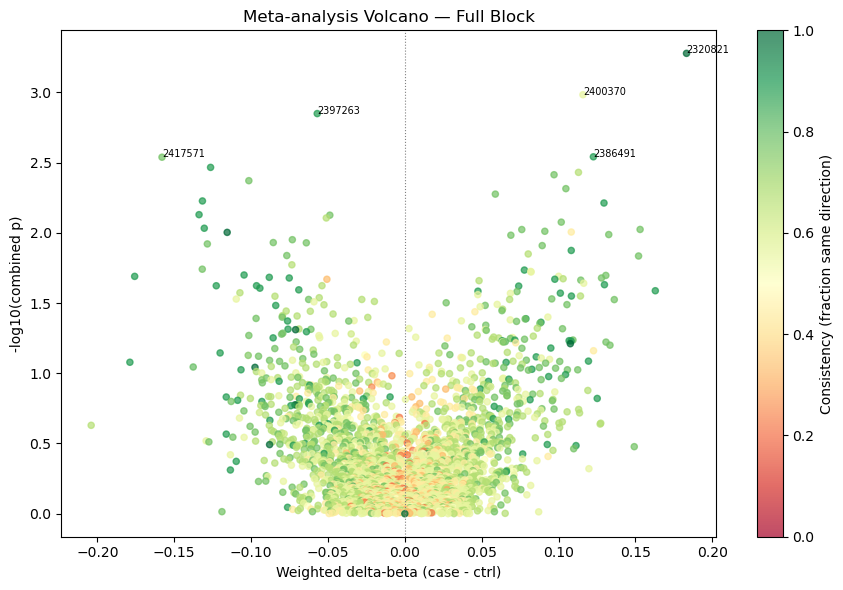

In [6]:
# Single view: fullblock — one panel
region = 'fullblock'
df = meta_results[region]

fig, ax = plt.subplots(figsize=(9, 6))

y_vals = -np.log10(df['combined_p'].clip(lower=1e-15))

sc = ax.scatter(
    df['weighted_delta_beta'],
    y_vals,
    c=df['consistency'],
    cmap='RdYlGn',
    vmin=0, vmax=1,
    alpha=0.7, s=20
)
plt.colorbar(sc, ax=ax, label='Consistency (fraction same direction)')

# FDR threshold line
fdr_thresh = df.loc[df['significant'], 'combined_p'].max() if df['significant'].any() else None
if fdr_thresh:
    ax.axhline(-np.log10(fdr_thresh), color='red', ls='--', lw=1, label='FDR=0.05 threshold')
    ax.legend(fontsize=8)

# Label top 5 CpGs
for _, row in df.head(5).iterrows():
    ax.annotate(
        str(row['cpg']),
        (row['weighted_delta_beta'], -np.log10(row['combined_p'])),
        fontsize=7, ha='left'
    )

ax.axvline(0, color='grey', ls=':', lw=0.8)
ax.set_xlabel('Weighted delta-beta (case - ctrl)')
ax.set_ylabel('-log10(combined p)')
ax.set_title('Meta-analysis Volcano — Full Block')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'meta_volcano_fullblock.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 7 — Top CpGs Summary Table

The most important output: ranked list of CpGs with the strongest consistent evidence across cohorts. For each top CpG, we show the delta beta per dataset so you can see which cohorts are driving the signal.

In [7]:
region = 'fullblock'
df = meta_results[region]
print(f'\n-- Top 10 CpGs -- FULLBLOCK --')
print(f'{"CpG":<15} {"Combined Z":>10} {"Combined p":>12} {"FDR p":>10} {"delta_beta":>12} {"Consistency":>12} {"N datasets":>10}')
print('-' * 85)
for _, row in df.head(10).iterrows():
    sig = '*' if row['significant'] else ''
    print(f'{str(row["cpg"]):<15} {row["combined_Z"]:>10.3f} {row["combined_p"]:>12.4f} '
          f'{row["p_fdr"]:>10.4f} {row["weighted_delta_beta"]:>12.4f} '
          f'{row["consistency"]:>12.2f} {row["n_datasets"]:>10}{sig}')
print('  * = FDR < 0.05')



-- Top 10 CpGs -- FULLBLOCK --
CpG             Combined Z   Combined p      FDR p   delta_beta  Consistency N datasets
-------------------------------------------------------------------------------------
2320821              3.466       0.0005     0.9880       0.1833         1.00          9
2400370              3.279       0.0010     0.9880       0.1159         0.56          9
2397263             -3.191       0.0014     0.9880      -0.0570         0.89          9
2386491              2.981       0.0029     0.9880       0.1227         0.89          9
2417571             -2.978       0.0029     0.9880      -0.1580         0.78          9
2375986             -2.927       0.0034     0.9880      -0.1264         0.89          9
2399112              2.901       0.0037     0.9880       0.1130         0.67          9
2399983              2.889       0.0039     0.9880       0.0971         0.78          9
2361549             -2.858       0.0043     0.9880      -0.1015         0.78          9
23

## Cell 8 — Cross-Reference with MOFA+ Weights

The CpGs driving MOFA+ Factor 3 (the factor shared across wildfire and cfDNA) should overlap with the top meta-analysis CpGs. If the same CpGs appear in both analyses independently, that's strong convergent evidence.

In [10]:
mofa_weights_path = TABLES_DIR / 'mofa_weights_fullblock.csv'

if mofa_weights_path.exists():
    mofa_w = pd.read_csv(mofa_weights_path, index_col=0)

    # ── Reconstruct aligned CpG order (mirrors 03_mofa.ipynb Cell 3 logic) ──
    MIN_COVERAGE_MOFA = 0.5
    datasets_with_fullblock = [ds for ds in beta if 'fullblock' in beta[ds]]
    n_groups = len(datasets_with_fullblock)

    all_cpgs_fb = sorted(set().union(*[
        set(beta[ds]['fullblock'].columns)
        for ds in datasets_with_fullblock
    ]))

    cpg_coverage = pd.DataFrame({
        ds: (~beta[ds]['fullblock'].isna().all(axis=0)).astype(int)
        for ds in datasets_with_fullblock
    })
    fraction_covered = cpg_coverage.sum(axis=1) / n_groups
    keep_cpgs_fb = sorted(fraction_covered[fraction_covered >= MIN_COVERAGE_MOFA].index)

    print(f'Aligned CpG list length : {len(keep_cpgs_fb)}')
    print(f'MOFA+ weight matrix rows: {len(mofa_w)}')

    # ── Map featureN_view0 → actual CpG position ──────────────────────────
    def map_feature(name):
        """Convert mofapy2 generic names (featureN_viewM) to real CpG positions."""
        try:
            idx = int(name.split('_')[0].replace('feature', ''))
            return str(keep_cpgs_fb[idx])
        except Exception:
            return name   # already a real name — pass through

    mofa_w.index = [map_feature(f) for f in mofa_w.index]
    print(f'First 3 CpGs after mapping: {mofa_w.index[:3].tolist()}')

    # ── Compare top CpGs from both methods ────────────────────────────────
    top_mofa = mofa_w['Factor1'].abs().sort_values(ascending=False).head(20).index.tolist()
    top_meta = meta_results['fullblock'].head(20)['cpg'].astype(str).tolist()

    print('\nTop 10 MOFA+ Factor1 CpGs (fullblock):')
    print(top_mofa)
    print('\nTop 20 meta-analysis CpGs (fullblock):')
    print(top_meta)

    overlap = set(top_mofa) & set(top_meta)
    print(f'\nOverlap: {len(overlap)} CpGs appear in both')
    if overlap:
        print('Shared CpGs:', overlap)
        print('\nThese CpGs have convergent evidence from two independent methods.')
        shared_df = meta_results['fullblock'][
            meta_results['fullblock']['cpg'].astype(str).isin(overlap)
        ][['cpg', 'combined_Z', 'combined_p', 'p_fdr',
           'weighted_delta_beta', 'consistency', 'n_datasets']]
        display(shared_df)
    else:
        print('No overlap in top CpGs — methods captured different aspects of variation.')
else:
    print(f'[SKIP] {mofa_weights_path.name} not found — run 03_mofa.ipynb first')

Aligned CpG list length : 2766
MOFA+ weight matrix rows: 2766
First 3 CpGs after mapping: ['2307563', '2307589', '2307675']

Top 10 MOFA+ Factor1 CpGs (fullblock):
['2374884', '2375069', '2376538', '2364028', '2358582', '2384093', '2358673', '2357390', '2376352', '2354038', '2376639', '2358279', '2374990', '2388846', '2384156', '2378743', '2404073', '2416040', '2356102', '2376249']

Top 20 meta-analysis CpGs (fullblock):
['2320821', '2400370', '2397263', '2386491', '2417571', '2375986', '2399112', '2399983', '2361549', '2368234', '2334824', '2363712', '2395730', '2425645', '2313512', '2356415', '2331161', '2428356', '2420816', '2401026']

Overlap: 0 CpGs appear in both
No overlap in top CpGs — methods captured different aspects of variation.


In [ ]:
'2374884', '2375069', '2376538', '2364028', '2358582', '2384093', '2358673', '2357390', '2376352', '2354038', '2376639', '2358279', '2374990', '2388846', '2384156', '2378743', '2404073', '2416040', '2356102', '2376249']
